# Graph Neural Networks for Molecular Dynamics
## The Hydrogen Molecule — Lennard-Jones Potential

---

**Course**: Machine Learning for Computational Physics  
**Stack**: Pure NumPy — every matrix, gradient, and integrator step is visible  

---

### What you will build

| Step | Component |
|------|-----------|
| 1 | Lennard-Jones physics for H$_2$ |
| 2 | Molecular graph: nodes, edges, features |
| 3 | Two-layer MLP with Xavier init, tanh, and manual backprop |
| 4 | InteractionNet GNN: message → aggregate → update → readout |
| 5 | Adam optimiser, MSE energy loss |
| 6 | Force prediction via central finite differences |
| 7 | Velocity-Verlet MD integrator |
| 8 | Comparison of GNN and exact LJ trajectories |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
import warnings; warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 12, 'axes.labelsize': 13,
    'axes.titlesize': 14, 'lines.linewidth': 2.0,
    'axes.grid': True, 'grid.alpha': 0.3,
})
print(f'NumPy {np.__version__}  |  ready')


NumPy 1.22.3  |  ready


---
## 1  Physics: the Hydrogen Molecule and the Lennard-Jones Potential

### 1.1  Born-Oppenheimer classical model

In the Born-Oppenheimer approximation the nuclear dynamics of H$_2$ are governed by
an effective potential $V(r)$ between the two protons at separation $r$.

### 1.2  Lennard-Jones (12-6) potential

$$\boxed{V_{\rm LJ}(r)=4\varepsilon\!\left[\left(\frac{\sigma}{r}\right)^{\!12}-\left(\frac{\sigma}{r}\right)^{\!6}\right]}$$

| Parameter | Physical meaning | Value (reduced units) |
|-----------|-----------------|----------------------|
| $\varepsilon$ | Well depth | $1$ |
| $\sigma$ | Zero-crossing distance | $1$ |
| $r_{\min}=2^{1/6}\sigma$ | Equilibrium bond length | $\approx 1.1225$ |

The **force** on atom $i$ from atom $j$:

$$\mathbf{F}_{ij}=-\nabla_{\mathbf{r}_i}V_{\rm LJ}(r_{ij})=\frac{24\varepsilon}{r_{ij}^{2}}\!\left[2\!\left(\frac{\sigma}{r_{ij}}\right)^{\!12}-\left(\frac{\sigma}{r_{ij}}\right)^{\!6}\right]\mathbf{r}_{ij},\qquad \mathbf{r}_{ij}=\mathbf{r}_i-\mathbf{r}_j$$

> **Units**: $\varepsilon=\sigma=m=1$ (reduced LJ units) throughout.


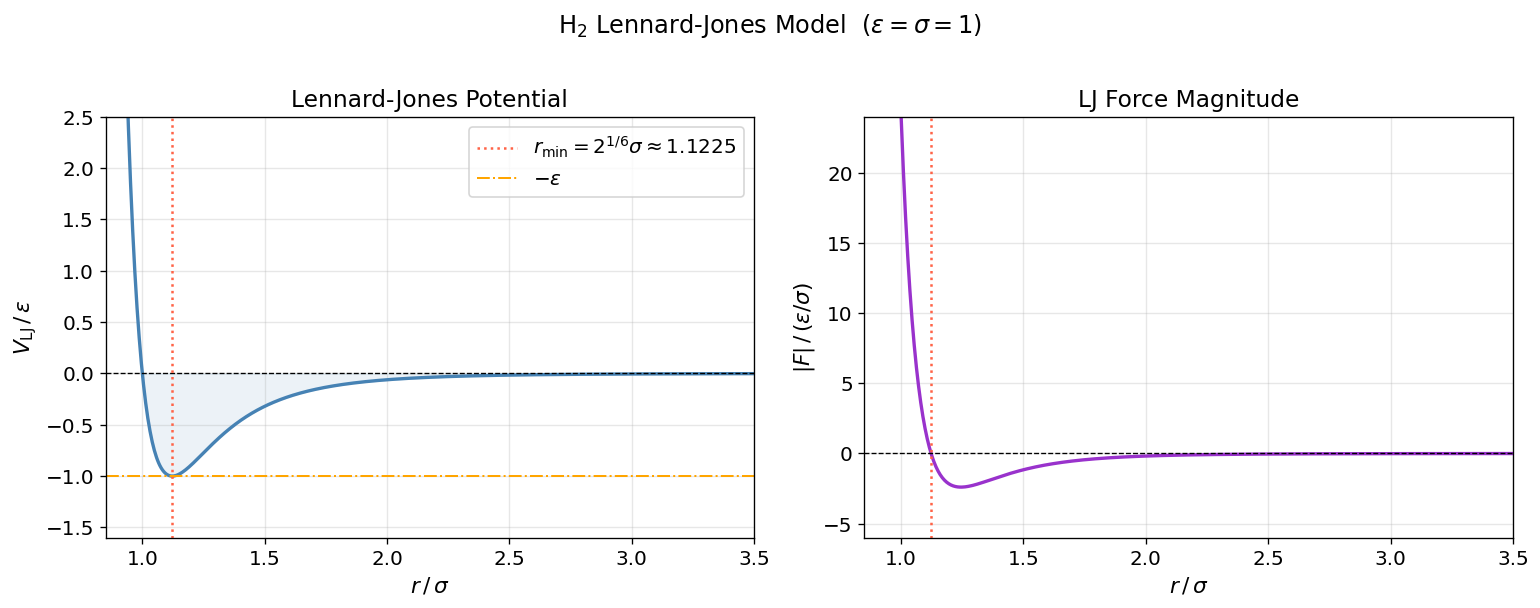

r_min    = 1.122462 sigma
V(r_min) = -1.000000 eps  (should be -1.0)
F(r_min) = -2.37e-15  (should be ~0)


In [2]:
# LJ parameters (reduced units)
EPS   = 1.0
SIGMA = 1.0
MASS  = 1.0
R_MIN = 2.0**(1.0/6.0)   # equilibrium ~ 1.1225 sigma


def lj_potential(r):
    s = (SIGMA / r)
    return 4.0 * EPS * (s**12 - s**6)


def lj_force_magnitude(r):
    s = (SIGMA / r)
    return (24.0 * EPS / r) * (2.0*s**12 - s**6)


def lj_force_vector(ri, rj):
    rij = ri - rj
    r2  = float(np.dot(rij, rij))
    s6  = (SIGMA**2 / r2)**3
    return (24.0 * EPS / r2) * (2.0*s6**2 - s6) * rij


rv = np.linspace(0.85, 3.5, 600)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(rv, lj_potential(rv), color='steelblue')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.axvline(R_MIN, color='tomato', lw=1.5, ls=':',
           label=rf'$r_{{\min}} = 2^{{1/6}}\sigma \approx {R_MIN:.4f}$')
ax.axhline(-EPS, color='orange', lw=1.2, ls='-.', label=r'$-\varepsilon$')
ax.fill_between(rv, lj_potential(rv), 0,
                where=(lj_potential(rv) < 0), alpha=0.10, color='steelblue')
ax.set(xlim=(0.85,3.5), ylim=(-1.6,2.5),
       xlabel=r'$r\,/\,\sigma$', ylabel=r'$V_{\rm LJ}\,/\,\varepsilon$',
       title='Lennard-Jones Potential')
ax.legend()

ax = axes[1]
ax.plot(rv, lj_force_magnitude(rv), color='darkorchid')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.axvline(R_MIN, color='tomato', lw=1.5, ls=':')
ax.set(xlim=(0.85,3.5), ylim=(-6,24),
       xlabel=r'$r\,/\,\sigma$', ylabel=r'$|F|\,/\,(\varepsilon/\sigma)$',
       title='LJ Force Magnitude')

fig.suptitle(r'H$_2$ Lennard-Jones Model  ($\varepsilon=\sigma=1$)', y=1.01)
plt.tight_layout(); plt.show()

print(f'r_min    = {R_MIN:.6f} sigma')
print(f'V(r_min) = {lj_potential(R_MIN):.6f} eps  (should be -1.0)')
print(f'F(r_min) = {lj_force_magnitude(R_MIN):.2e}  (should be ~0)')


---
## 2  Graph Representation of the Molecular System

### 2.1  Molecules as graphs

$$G = \bigl(V,\; E,\; \{\mathbf{h}_i^{(0)}\}_{i\in V},\; \{\mathbf{e}_{ij}\}_{(i,j)\in E}\bigr)$$

| Symbol | Meaning |
|--------|---------|
| $V=\{0,\ldots,N-1\}$ | Atoms (nodes) |
| $E\subseteq V\times V$ | Directed interactions (edges) |
| $\mathbf{h}_i^{(0)}\in\mathbb{R}^{d_v}$ | Initial node feature for atom $i$ |
| $\mathbf{e}_{ij}\in\mathbb{R}^{d_e}$ | Edge feature for ordered pair $(i,j)$ |

### 2.2  Rotation-invariant features for H$_2$

$$\mathbf{h}_i^{(0)}=\begin{pmatrix}Z_i \\ m_i \\ \|\mathbf{r}_i\|\end{pmatrix}\in\mathbb{R}^3,\qquad\mathbf{e}_{ij}=\begin{pmatrix}r_{ij}\\ r_{ij}^{-1}\\ (\sigma/r_{ij})^6\end{pmatrix}\in\mathbb{R}^3$$

$Z_i$ = atomic number, $m_i$ = mass. Edge features encode the LJ interaction terms.

### 2.3  Graph Laplacian

The **graph Laplacian** $L=D-A$ ($D$=degree matrix, $A$=adjacency). For H$_2$:

$$L=\begin{pmatrix}1&-1\\-1&1\end{pmatrix},\quad\lambda(L)=\{0,\,2\}$$

The zero eigenvalue encodes translation invariance; the eigenvalue 2 reflects the bond.


In [3]:
class MolecularGraph:
    # Rotation-invariant graph representation of a molecule.
    #
    # Attributes
    # ----------
    # positions   (N, d)      atomic positions
    # node_feats  (N, d_v)    initial node feature matrix  H^(0)
    # edge_index  (2, |E|)    directed edge connectivity  [src; dst]
    # edge_feats  (|E|, d_e)  edge feature matrix
    # adj         (N, N)      adjacency matrix  A
    # laplacian   (N, N)      graph Laplacian   L = D - A

    def __init__(self, positions, atomic_numbers, masses, cutoff=np.inf):
        self.positions      = np.asarray(positions, float)
        self.atomic_numbers = np.asarray(atomic_numbers)
        self.masses         = np.asarray(masses, float)
        self.N              = len(self.positions)
        self.d              = self.positions.shape[1]
        self._build(cutoff)

    def _build(self, cutoff):
        pos = self.positions; N = self.N
        norms = np.linalg.norm(pos, axis=1, keepdims=True)
        # node features h_i = [Z_i, m_i, ||r_i||]
        self.node_feats = np.hstack([
            self.atomic_numbers[:, None].astype(float),
            self.masses[:, None], norms
        ])
        src, dst, ef = [], [], []
        adj = np.zeros((N, N))
        for i in range(N):
            for j in range(N):
                if i == j: continue
                r = np.linalg.norm(pos[i] - pos[j])
                if r <= cutoff:
                    src.append(i); dst.append(j); adj[i, j] = 1.0
                    ef.append([r, 1.0/r, (SIGMA/r)**6])
        self.edge_index = np.array([src, dst], dtype=int)
        self.edge_feats = np.array(ef, float)
        self.adj        = adj
        D               = np.diag(adj.sum(axis=1))
        self.laplacian  = D - adj

    def __repr__(self):
        return (f'MolecularGraph(N={self.N}, d={self.d}, '
                f'|E|={self.edge_index.shape[1]}, '
                f'd_v={self.node_feats.shape[1]}, '
                f'd_e={self.edge_feats.shape[1]})')


# Build H2 at equilibrium geometry
pos0     = np.array([[-R_MIN/2, 0.0], [+R_MIN/2, 0.0]])
graph_eq = MolecularGraph(pos0, [1, 1], [1.0, 1.0])

print(graph_eq, '\n')
print('Node feature matrix  H^(0)  [Z, mass, |r|]:')
for i, h in enumerate(graph_eq.node_feats):
    print(f'  atom {i}: {h}')
print('\nEdge features  [r, 1/r, (sigma/r)^6]:')
for k in range(graph_eq.edge_index.shape[1]):
    i, j = graph_eq.edge_index[:, k]
    print(f'  {i}->{j}: {graph_eq.edge_feats[k]}')
print('\nLaplacian eigenvalues:', np.linalg.eigvalsh(graph_eq.laplacian))


MolecularGraph(N=2, d=2, |E|=2, d_v=3, d_e=3) 

Node feature matrix  H^(0)  [Z, mass, |r|]:
  atom 0: [1.         1.         0.56123102]
  atom 1: [1.         1.         0.56123102]

Edge features  [r, 1/r, (sigma/r)^6]:
  0->1: [1.12246205 0.89089872 0.5       ]
  1->0: [1.12246205 0.89089872 0.5       ]

Laplacian eigenvalues: [0. 2.]


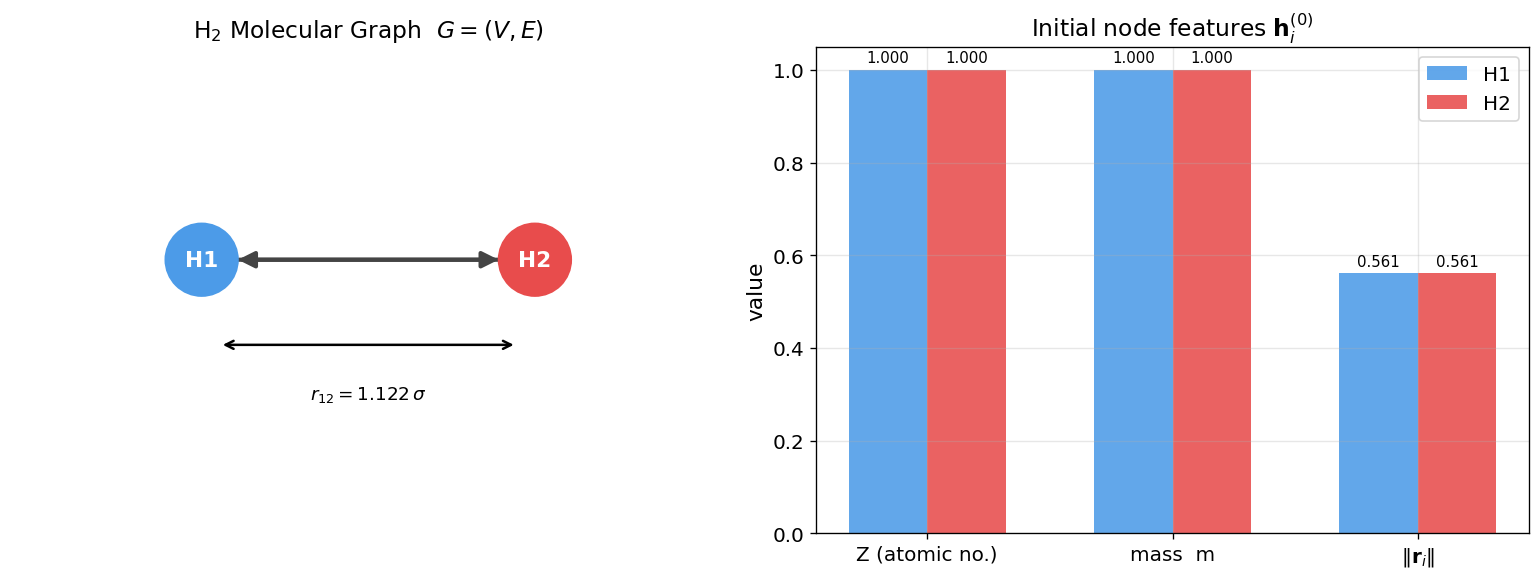

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
G  = nx.DiGraph(); G.add_edges_from([(0,1),(1,0)])
npos = {0: (-R_MIN/2, 0), 1: (R_MIN/2, 0)}
nx.draw_networkx(G, pos=npos, ax=ax,
                 labels={0:'H1', 1:'H2'},
                 node_color=['#4C9BE8','#E84C4C'],
                 node_size=1900, font_color='white',
                 font_size=13, font_weight='bold',
                 edge_color='#444', width=2.5, arrowsize=20)
ax.annotate('', xy=(R_MIN/2-0.06,-0.14), xytext=(-R_MIN/2+0.06,-0.14),
            arrowprops=dict(arrowstyle='<->', color='k', lw=1.5))
ax.text(0,-0.23, rf'$r_{{12}}={R_MIN:.3f}\,\sigma$', ha='center', fontsize=11)
ax.set(title=r'H$_2$ Molecular Graph  $G=(V,E)$',
       xlim=(-1.2,1.2), ylim=(-0.45,0.35))
ax.axis('off')

ax = axes[1]
labels = ['Z (atomic no.)', 'mass  m', r'$\|\mathbf{r}_i\|$']
x, w = np.arange(3), 0.32
b0 = ax.bar(x-w/2, graph_eq.node_feats[0], w, color='#4C9BE8', label='H1', alpha=0.88)
b1 = ax.bar(x+w/2, graph_eq.node_feats[1], w, color='#E84C4C', label='H2', alpha=0.88)
for b in list(b0)+list(b1):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
            f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=9)
ax.set(xticks=x, xticklabels=labels,
       title=r'Initial node features $\mathbf{h}_i^{(0)}$', ylabel='value')
ax.legend()
plt.tight_layout(); plt.show()


---
## 3  GNN Mathematics: Message Passing, Aggregation, Update

### 3.1  General message-passing framework (Gilmer et al., 2017)

At each layer $\ell$, every node $i$ collects messages from its neighbours:

$$\boxed{\mathbf{h}_i^{(\ell+1)}= U^{(\ell)}\!\left(\mathbf{h}_i^{(\ell)},\;\bigoplus_{j\in\mathcal{N}(i)}M^{(\ell)}\!\left(\mathbf{h}_i^{(\ell)},\,\mathbf{h}_j^{(\ell)},\,\mathbf{e}_{ij}\right)\right)}$$

| Symbol | Role |
|--------|----- |
| $\mathbf{h}_i^{(\ell)}$ | Hidden state of node $i$ at layer $\ell$ |
| $M^{(\ell)}$ | **Message function** (edge-wise) |
| $\bigoplus$ | **Aggregation** — here: $\sum$ (permutation-invariant) |
| $U^{(\ell)}$ | **Update function** (node-wise) |

### 3.2  InteractionNet architecture (Battaglia et al., 2016)

**Step 1 — message (edge-wise):**
$$\mathbf{m}_{ij}^{(\ell)}= \phi_M^{(\ell)}\!\begin{bmatrix}\mathbf{h}_i^{(\ell)}\\\mathbf{h}_j^{(\ell)}\\\mathbf{e}_{ij}\end{bmatrix}\in\mathbb{R}^{d_h},\quad\phi_M:\mathbb{R}^{2d_v+d_e}\to\mathbb{R}^{d_h}$$

**Step 2 — sum aggregation (node-wise):**
$$\bar{\mathbf{m}}_i^{(\ell)}=\sum_{j\in\mathcal{N}(i)}\mathbf{m}_{ij}^{(\ell)}$$

**Step 3 — update (node-wise):**
$$\mathbf{h}_i^{(\ell+1)}= \phi_U^{(\ell)}\!\begin{bmatrix}\mathbf{h}_i^{(\ell)}\\\bar{\mathbf{m}}_i^{(\ell)}\end{bmatrix}\in\mathbb{R}^{d_v},\quad\phi_U:\mathbb{R}^{d_v+d_h}\to\mathbb{R}^{d_v}$$

**Step 4 — global readout:**
$$\hat{E}=\mathbf{w}^{\top}\!\sum_{i\in V}\mathbf{h}_i^{(L)}+b$$

### 3.3  Physical symmetries

Using only distances as edge features makes $\hat{E}$ **invariant** under global
rotation and translation. Sum aggregation gives **permutation invariance**.

### 3.4  Forces from the GNN

$$\hat{\mathbf{F}}_i=-\nabla_{\mathbf{r}_i}\hat{E}\approx -\frac{\hat{E}(\mathbf{r}+h\hat{\mathbf{e}}_{i\alpha})-\hat{E}(\mathbf{r}-h\hat{\mathbf{e}}_{i\alpha})}{2h},\quad h=10^{-5}\sigma$$

### 3.5  Layer dimensions

| Quantity | Value |
|----------|-------|
| Node feature dim $d_v$ | 3 |
| Edge feature dim $d_e$ | 3 |
| Message MLP input $2d_v+d_e$ | 9 |
| Hidden dim $d_h$ | 32 |
| MP layers $L$ | 3 |


In [5]:
# activation and its derivative
def tanh_act(x): return np.tanh(x)
def tanh_d(x):   t = np.tanh(x); return 1.0 - t*t


class Linear:
    # Affine layer:  y = W x + b,  Xavier-uniform initialisation.
    # Forward: y = W x + b
    # Backward: accumulates dW, db; returns dx

    def __init__(self, d_in, d_out):
        lim      = np.sqrt(6.0 / (d_in + d_out))
        self.W   = np.random.uniform(-lim, lim, (d_out, d_in))
        self.b   = np.zeros(d_out)
        self.dW  = np.zeros_like(self.W)
        self.db  = np.zeros_like(self.b)
        self._x  = None

    def forward(self, x):
        self._x = x
        return self.W @ x + self.b

    def backward(self, dy):
        self.dW += np.outer(dy, self._x)
        self.db += dy
        return self.W.T @ dy

    def zero_grad(self): self.dW[:] = 0.0; self.db[:] = 0.0
    def n_params(self):  return self.W.size + self.b.size


class MLP2:
    # Two-layer MLP: x -> Linear(d_in,d_h) -> tanh -> Linear(d_h,d_out)
    # Manual backpropagation.

    def __init__(self, d_in, d_h, d_out):
        self.fc1 = Linear(d_in, d_h)
        self.fc2 = Linear(d_h,  d_out)
        self._z1 = None

    def forward(self, x):
        z1       = self.fc1.forward(x); self._z1 = z1
        return self.fc2.forward(tanh_act(z1))

    def backward(self, dy):
        da1 = self.fc2.backward(dy)
        dz1 = da1 * tanh_d(self._z1)
        return self.fc1.backward(dz1)

    def zero_grad(self): self.fc1.zero_grad(); self.fc2.zero_grad()
    def sublayers(self): return [self.fc1, self.fc2]
    def n_params(self):  return self.fc1.n_params() + self.fc2.n_params()


print('Building blocks defined.')
print(f'  Linear(9, 32)   -> {Linear(9,32).n_params()} parameters')
print(f'  MLP2(9, 32, 32) -> {MLP2(9,32,32).n_params()} parameters')


Building blocks defined.
  Linear(9, 32)   -> 320 parameters
  MLP2(9, 32, 32) -> 1376 parameters


---
## 4  The Full GNN: InteractionNet

### 4.1  Backpropagation through message passing

The gradient of the MSE loss with respect to message MLP weights at layer $\ell$:

$$\frac{\partial\mathcal{L}}{\partial W_M^{(\ell)}}=\sum_{(i,j)\in E}\frac{\partial\mathcal{L}}{\partial\mathbf{m}_{ij}^{(\ell)}}\cdot\frac{\partial\mathbf{m}_{ij}^{(\ell)}}{\partial W_M^{(\ell)}}$$

The aggregation step scatters gradients from each receiver node back to all
incoming messages; the message backward pass then splits them between
the source node $i$ and target node $j$.

### 4.2  Readout gradient

$$\hat{E}=\mathbf{w}^{\top}\!\underbrace{\sum_i\mathbf{h}_i^{(L)}}_{\text{pool}}+b \quad\Rightarrow\quad\frac{\partial\mathcal{L}}{\partial\mathbf{h}_i^{(L)}}=\frac{\partial\mathcal{L}}{\partial\hat{E}}\cdot\mathbf{w}$$


In [6]:
class InteractionNetGNN:
    # Energy-predicting GNN with L message-passing layers.
    #
    # Forward pass:
    #   for l in 0..L-1:
    #     m_ij^(l) = MLP_msg^(l)( [h_i^(l); h_j^(l); e_ij] )   message
    #     agg_i    = sum_{j in N(i)} m_ij^(l)                   aggregate
    #     h_i^(l+1)= MLP_upd^(l)( [h_i^(l); agg_i] )           update
    #   E_hat = w.T @ (sum_i h_i^(L)) + b                       readout

    def __init__(self, d_v=3, d_e=3, d_h=32, L=3):
        self.d_v=d_v; self.d_e=d_e; self.d_h=d_h; self.L=L
        # message MLPs: input [h_i; h_j; e_ij] of dim 2*d_v + d_e
        self.msg = [MLP2(2*d_v+d_e, d_h, d_h) for _ in range(L)]
        # update  MLPs: input [h_i; agg_i] of dim d_v + d_h
        self.upd = [MLP2(d_v+d_h,   d_h, d_v) for _ in range(L)]
        self.w_ro  = np.random.randn(d_v) * 0.1
        self.b_ro  = 0.0
        self.dw_ro = np.zeros(d_v); self.db_ro = 0.0
        # caches
        self._H_layers=[]; self._msgs=[]; self._aggs=[]
        self._H_out=None; self._graph=None

    # ---------- forward ----------
    def forward(self, graph):
        self._graph=graph; N=graph.N
        ei=graph.edge_index; ef=graph.edge_feats
        H=graph.node_feats.copy()
        self._H_layers=[H.copy()]; self._msgs=[]; self._aggs=[]

        for l in range(self.L):
            n_e=ei.shape[1]; M_all=np.zeros((n_e,self.d_h))
            # Step 1: messages
            for k in range(n_e):
                i,j=ei[0,k],ei[1,k]
                inp=np.concatenate([H[i],H[j],ef[k]])
                M_all[k]=self.msg[l].forward(inp)
            # Step 2: aggregate (sum)
            agg=np.zeros((N,self.d_h))
            for k in range(n_e): agg[ei[0,k]]+=M_all[k]
            # Step 3: update
            H_new=np.zeros((N,self.d_v))
            for i in range(N):
                H_new[i]=self.upd[l].forward(np.concatenate([H[i],agg[i]]))
            self._msgs.append(M_all); self._aggs.append(agg)
            H=H_new; self._H_layers.append(H.copy())

        # Step 4: readout  E_hat = w.T @ pool + b
        self._H_out=H
        return float(self.w_ro @ H.sum(axis=0) + self.b_ro)

    # ---------- backward ----------
    def backward(self, dE_hat=1.0):
        graph=self._graph; N=graph.N
        ei=graph.edge_index; ef=graph.edge_feats

        # readout backward
        self.dw_ro += dE_hat * self._H_out.sum(axis=0)
        self.db_ro += dE_hat
        dH = np.tile(dE_hat * self.w_ro, (N,1))

        for l in reversed(range(self.L)):
            H_prev=self._H_layers[l]; agg=self._aggs[l]
            M_all=self._msgs[l]; n_e=ei.shape[1]

            # update backward
            d_cat=np.zeros((N,self.d_v+self.d_h))
            for i in range(N):
                d_cat[i]=self.upd[l].backward(dH[i])
            dH_upd=d_cat[:,:self.d_v]
            d_agg =d_cat[:,self.d_v:]

            # aggregate backward: scatter d_agg to incoming edges
            dM=np.zeros((n_e,self.d_h))
            for k in range(n_e): dM[k]+=d_agg[ei[0,k]]

            # message backward
            dH_msg=np.zeros((N,self.d_v))
            for k in range(n_e):
                i,j=ei[0,k],ei[1,k]
                d_inp=self.msg[l].backward(dM[k])
                dH_msg[i]+=d_inp[:self.d_v]
                dH_msg[j]+=d_inp[self.d_v:2*self.d_v]

            dH=dH_upd+dH_msg
        return dH

    # ---------- utilities ----------
    def zero_grad(self):
        for m in self.msg+self.upd: m.zero_grad()
        self.dw_ro[:]=0.0; self.db_ro=0.0

    def _all_linears(self):
        out=[]
        for m in self.msg+self.upd: out.extend(m.sublayers())
        return out

    def flat_params(self):
        ls=self._all_linears()
        return np.concatenate([l.W.ravel() for l in ls]+
                              [l.b.ravel() for l in ls]+
                              [self.w_ro,[self.b_ro]])

    def flat_grads(self):
        ls=self._all_linears()
        return np.concatenate([l.dW.ravel() for l in ls]+
                              [l.db.ravel() for l in ls]+
                              [self.dw_ro,[self.db_ro]])

    def set_flat_params(self, p):
        ls=self._all_linears(); idx=0
        for l in ls:
            n=l.W.size; l.W[:]=p[idx:idx+n].reshape(l.W.shape); idx+=n
        for l in ls:
            n=l.b.size; l.b[:]=p[idx:idx+n]; idx+=n
        n=self.w_ro.size; self.w_ro[:]=p[idx:idx+n]; idx+=n
        self.b_ro=float(p[idx])

    def n_params(self):
        return (sum(m.n_params() for m in self.msg+self.upd)
                + self.w_ro.size + 1)


gnn = InteractionNetGNN(d_v=3, d_e=3, d_h=32, L=3)
print('InteractionNet GNN')
print(f'  L={gnn.L},  d_v={gnn.d_v},  d_h={gnn.d_h}')
print(f'  Total parameters: {gnn.n_params():,}')
E_test = gnn.forward(graph_eq)
print(f'  Test forward: E_hat = {E_test:.6f}  (random init)')
gnn.backward(1.0)
print(f'  Gradient norm = {np.linalg.norm(gnn.flat_grads()):.4f}  (backprop OK)')


InteractionNet GNN
  L=3,  d_v=3,  d_h=32
  Total parameters: 7,885
  Test forward: E_hat = 0.216879  (random init)
  Gradient norm = 2.4796  (backprop OK)


---
## 5  Training the GNN

### 5.1  Dataset

We sample $N_{\rm train}=200$ bond lengths $r\sim\mathrm{Uniform}(0.90,\,3.0)\,\sigma$
and z-score normalise the LJ energies before training.

### 5.2  MSE loss

$$\mathcal{L}(\phi)=\frac{1}{N_{\rm train}}\sum_n\!\left(\hat{E}_n(\phi)-\tilde{E}_n^{\rm LJ}\right)^2,\qquad \tilde{E}=\frac{E-\mu_E}{\sigma_E}$$

### 5.3  Adam optimiser (Kingma & Ba, 2015)

$$\phi_{t+1}=\phi_t-\frac{\eta}{\sqrt{\hat{v}_t}+\varepsilon_{\rm Adam}}\hat{m}_t,\quad \hat{m}_t=\frac{m_t}{1-\beta_1^t},\;\hat{v}_t=\frac{v_t}{1-\beta_2^t}$$

Defaults: $\eta=5\times10^{-3}$, $\beta_1=0.9$, $\beta_2=0.999$.


In [7]:
def graph_from_r(r):
    pos = np.array([[-r/2, 0.0], [+r/2, 0.0]])
    return MolecularGraph(pos, [1,1], [1.0,1.0])


N_TRAIN, N_VAL = 200, 60
r_train = np.random.uniform(0.90, 3.0, N_TRAIN)
r_val   = np.linspace(0.90, 3.0, N_VAL)
E_train_raw = lj_potential(r_train)
E_val_raw   = lj_potential(r_val)
mu_E  = E_train_raw.mean()
sig_E = E_train_raw.std() + 1e-9
E_train_n = (E_train_raw - mu_E) / sig_E
E_val_n   = (E_val_raw   - mu_E) / sig_E
print(f'Train: {N_TRAIN} configs,  mu_E={mu_E:.4f},  sig_E={sig_E:.4f}')


class Adam:
    def __init__(self, n, lr=5e-3, b1=0.9, b2=0.999, eps=1e-8):
        self.lr,self.b1,self.b2,self.eps=lr,b1,b2,eps
        self.m=np.zeros(n); self.v=np.zeros(n); self.t=0
    def step(self, p, g):
        self.t+=1
        self.m=self.b1*self.m+(1-self.b1)*g
        self.v=self.b2*self.v+(1-self.b2)*g**2
        mh=self.m/(1-self.b1**self.t); vh=self.v/(1-self.b2**self.t)
        return p - self.lr*mh/(np.sqrt(vh)+self.eps)


gnn = InteractionNetGNN(d_v=3, d_e=3, d_h=32, L=3)
opt = Adam(gnn.n_params())
N_EPOCHS = 800
hist = {'train':[], 'val':[]}

for epoch in range(N_EPOCHS):
    gnn.zero_grad(); total=0.0
    for n in np.random.permutation(N_TRAIN):
        err = gnn.forward(graph_from_r(r_train[n])) - E_train_n[n]
        total += err**2
        gnn.backward(dE_hat=2.0*err)
    p=gnn.flat_params(); g=gnn.flat_grads()/N_TRAIN
    gnn.set_flat_params(opt.step(p, g))
    hist['train'].append(total/N_TRAIN)
    vl=np.mean([(gnn.forward(graph_from_r(r_val[n]))-E_val_n[n])**2
                for n in range(N_VAL)])
    hist['val'].append(vl)
    if epoch%100==0 or epoch==N_EPOCHS-1:
        print(f'epoch {epoch:4d}  train={hist["train"][-1]:.5f}  val={vl:.5f}')

print('Training complete.')


Train: 200 configs,  mu_E=-0.0783,  sig_E=0.6883
epoch    0  train=1.15023  val=2.22117
epoch  100  train=0.00095  val=0.12194
epoch  200  train=0.00011  val=0.08818
epoch  300  train=0.00020  val=0.10530
epoch  400  train=0.00006  val=0.09536
epoch  500  train=0.00281  val=0.09467
epoch  600  train=0.00054  val=0.09380
epoch  700  train=0.00112  val=0.10680
epoch  799  train=0.00011  val=0.10408
Training complete.


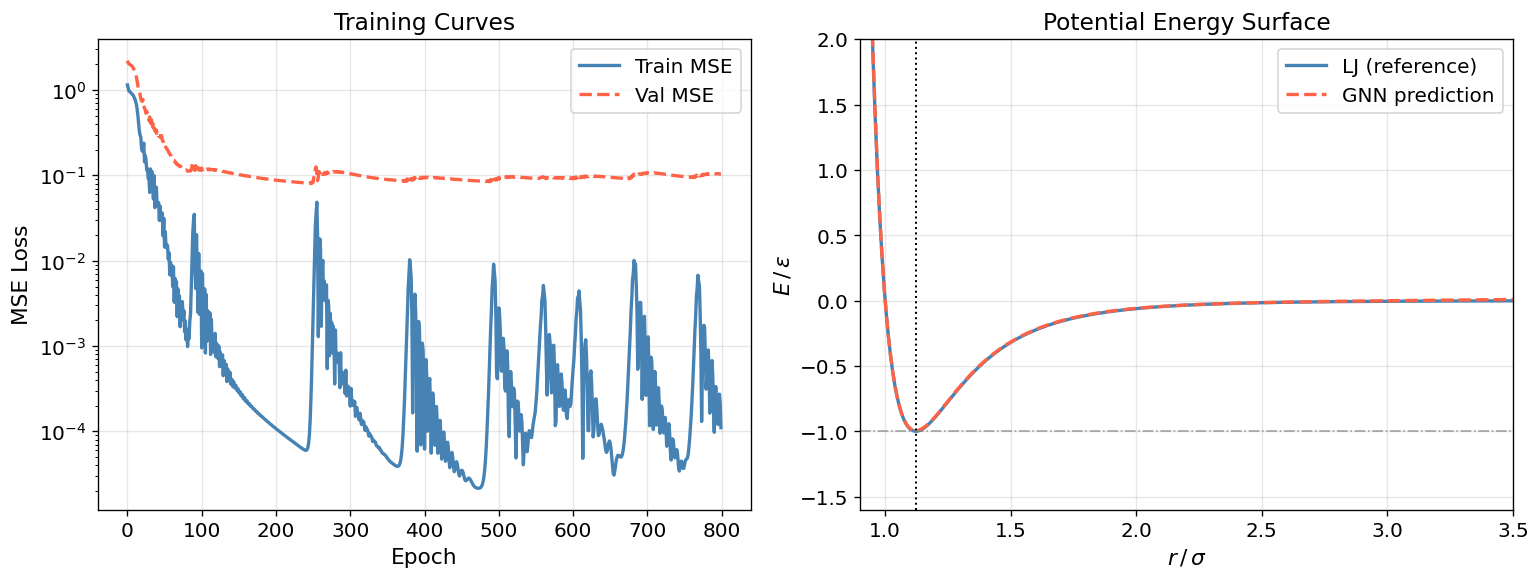

Energy RMSE = 0.10677 eps  (10.68% of well depth)
GNN r_min ~ 1.1261 sigma   (ref: 1.1225 sigma)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.semilogy(hist['train'], color='steelblue', label='Train MSE')
ax.semilogy(hist['val'],   color='tomato',    label='Val MSE', ls='--')
ax.set(xlabel='Epoch', ylabel='MSE Loss', title='Training Curves')
ax.legend()

ax = axes[1]
r_plot = np.linspace(0.90, 3.5, 300)
E_lj   = lj_potential(r_plot)
E_gnn  = np.array([gnn.forward(graph_from_r(r))*sig_E+mu_E for r in r_plot])
ax.plot(r_plot, E_lj,  color='steelblue', lw=2, label='LJ (reference)')
ax.plot(r_plot, E_gnn, color='tomato',    lw=2, ls='--', label='GNN prediction')
ax.axvline(R_MIN, color='k', ls=':', lw=1.2)
ax.axhline(-EPS,  color='grey', ls='-.', lw=1.0, alpha=0.7)
ax.set(xlim=(0.90,3.5), ylim=(-1.6,2.0),
       xlabel=r'$r\,/\,\sigma$', ylabel=r'$E\,/\,\varepsilon$',
       title='Potential Energy Surface')
ax.legend()
plt.tight_layout(); plt.show()

rmse = np.sqrt(np.mean((E_gnn-E_lj)**2))
print(f'Energy RMSE = {rmse:.5f} eps  ({100*rmse:.2f}% of well depth)')
print(f'GNN r_min ~ {r_plot[E_gnn.argmin()]:.4f} sigma   (ref: {R_MIN:.4f} sigma)')


---
## 6  Force Prediction

Forces are obtained by differentiating the predicted energy with respect to positions.
Since the GNN uses only invariant distance features, we apply **central finite differences**:

$$\hat{F}_{i\alpha}\approx -\frac{\hat{E}(\mathbf{r}+h\hat{\mathbf{e}}_{i\alpha})-\hat{E}(\mathbf{r}-h\hat{\mathbf{e}}_{i\alpha})}{2h},\quad h=10^{-5}\,\sigma$$

Newton's third law $\mathbf{F}_{01}=-\mathbf{F}_{10}$ is automatically satisfied
because the potential depends only on the symmetric quantity $r_{01}=\|\mathbf{r}_0-\mathbf{r}_1\|$.


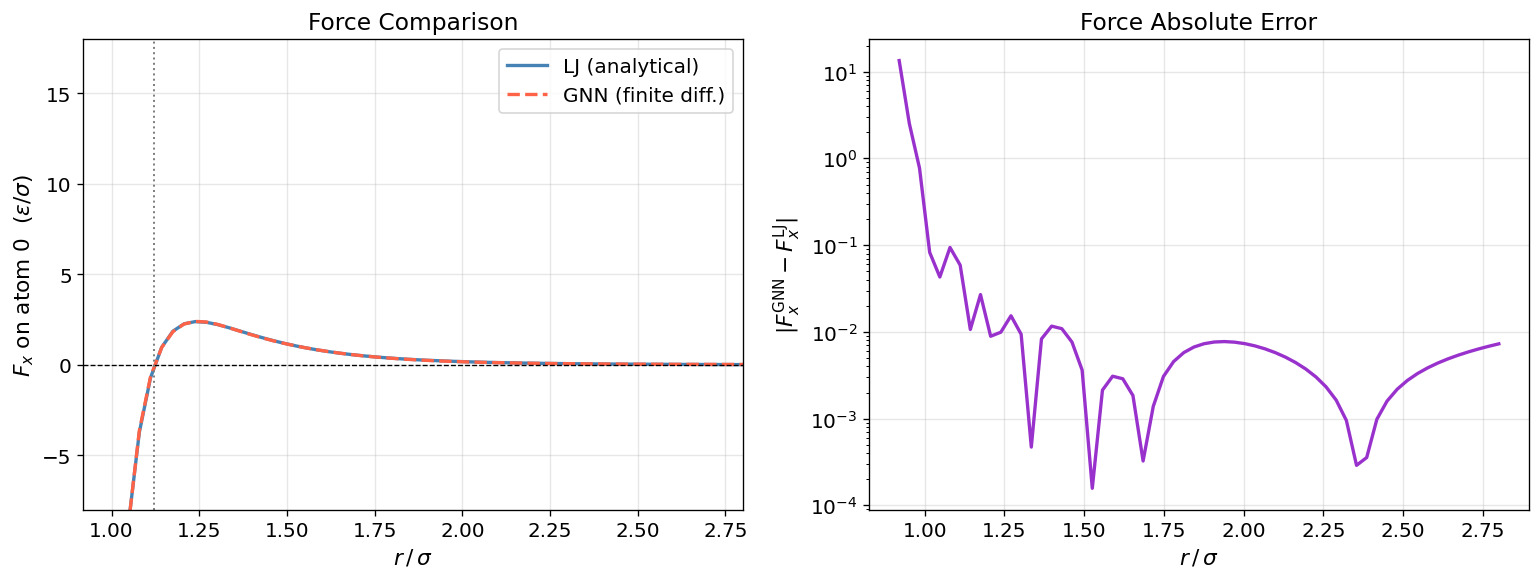

Mean force error: 0.28790 eps/sigma
Max  force error: 13.41248 eps/sigma  at r=0.920


In [9]:
def gnn_energy(pos, model):
    g = MolecularGraph(pos, [1,1], [1.0,1.0])
    return model.forward(g)*sig_E + mu_E


def gnn_forces(pos, model, h=1e-5):
    # Central-difference forces:  F[i,a] = -(E(r+h e_ia) - E(r-h e_ia)) / (2h)
    pos=np.array(pos,float); N,d=pos.shape; F=np.zeros_like(pos)
    for i in range(N):
        for a in range(d):
            pp=pos.copy(); pp[i,a]+=h
            pm=pos.copy(); pm[i,a]-=h
            F[i,a]=-(gnn_energy(pp,model)-gnn_energy(pm,model))/(2*h)
    return F


def lj_forces_all(pos):
    pos=np.array(pos,float); N=pos.shape[0]
    F=np.zeros_like(pos)
    for i in range(N):
        for j in range(N):
            if i!=j: F[i]+=lj_force_vector(pos[i],pos[j])
    return F


r_f = np.linspace(0.92, 2.8, 60)
Fx_lj, Fx_gnn = [], []
for r in r_f:
    pos=np.array([[-r/2,0.0],[+r/2,0.0]])
    Fx_lj .append(lj_forces_all(pos)[0,0])
    Fx_gnn.append(gnn_forces(pos,gnn)[0,0])
Fx_lj=np.array(Fx_lj); Fx_gnn=np.array(Fx_gnn); F_err=np.abs(Fx_gnn-Fx_lj)

fig, axes = plt.subplots(1, 2, figsize=(13,5))

ax=axes[0]
ax.plot(r_f, Fx_lj,  color='steelblue', lw=2, label='LJ (analytical)')
ax.plot(r_f, Fx_gnn, color='tomato',    lw=2, ls='--', label='GNN (finite diff.)')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.axvline(R_MIN, color='grey', lw=1.2, ls=':')
ax.set(xlim=(0.92,2.8), ylim=(-8,18),
       xlabel=r'$r\,/\,\sigma$',
       ylabel=r'$F_x$ on atom 0  $(\varepsilon/\sigma)$',
       title='Force Comparison')
ax.legend()

ax=axes[1]
ax.semilogy(r_f, F_err+1e-9, color='darkorchid', lw=2)
ax.set(xlabel=r'$r\,/\,\sigma$',
       ylabel=r'$|F_x^{\rm GNN}-F_x^{\rm LJ}|$',
       title='Force Absolute Error')
plt.tight_layout(); plt.show()

print(f'Mean force error: {F_err.mean():.5f} eps/sigma')
print(f'Max  force error: {F_err.max():.5f} eps/sigma  at r={r_f[F_err.argmax()]:.3f}')


---
## 7  Velocity-Verlet Molecular Dynamics

### 7.1  Equations of motion

$$m_i\ddot{\mathbf{r}}_i = \mathbf{F}_i(\{\mathbf{r}_j\})$$

### 7.2  Velocity-Verlet integrator

The algorithm is **symplectic** (preserves phase-space volume) and
**time-reversible** (second-order accurate in $\Delta t$):

$$\mathbf{r}_i(t+\Delta t)=\mathbf{r}_i(t)+\mathbf{v}_i(t)\Delta t+\frac{\mathbf{F}_i(t)}{2m_i}(\Delta t)^2$$

$$\mathbf{v}_i(t+\Delta t)=\mathbf{v}_i(t)+\frac{\mathbf{F}_i(t)+\mathbf{F}_i(t+\Delta t)}{2m_i}\Delta t$$

Only **one** force evaluation per step: $\mathbf{F}(t+\Delta t)$ is reused
as the old force in the next step.

### 7.3  Energy conservation diagnostic

$$\delta E_{\rm tot}=\frac{\mathrm{std}(E_{\rm tot}(t))}{|\bar{E}_{\rm tot}|}\ll 1$$

For the Velocity-Verlet integrator, $\delta E_{\rm tot}\propto(\Delta t)^2$.


In [10]:
def velocity_verlet(pos0, vel0, masses, force_fn, dt, n_steps):
    # Velocity-Verlet integrator.
    # r(t+dt) = r(t) + v(t)*dt + F(t)/(2m)*dt^2
    # v(t+dt) = v(t) + (F(t)+F(t+dt))/(2m)*dt
    r=pos0.copy(); v=vel0.copy(); m=masses[:,None]
    F=force_fn(r)
    traj={k:[] for k in ('r','v','Ek','Ep','Etot','t')}
    for step in range(n_steps):
        Ek=0.5*float((masses*(v**2).sum(axis=1)).sum())
        Ep=float(lj_potential(np.linalg.norm(r[0]-r[1])))
        for k,val in zip(('r','v','Ek','Ep','Etot','t'),
                         (r.copy(),v.copy(),Ek,Ep,Ek+Ep,step*dt)):
            traj[k].append(val)
        r_new=r+v*dt+0.5*(F/m)*dt**2
        F_new=force_fn(r_new)
        v=v+0.5*(F+F_new)/m*dt
        r,F=r_new,F_new
    for k in traj: traj[k]=np.array(traj[k])
    return traj


DT=0.005; N_STEPS=2000
r_init=R_MIN*1.08
pos0=np.array([[-r_init/2,0.0],[+r_init/2,0.0]])
vel0=np.array([[0.06,0.0],[-0.06,0.0]])
masses=np.array([MASS,MASS])

print('Running LJ MD (reference)...')
traj_lj=velocity_verlet(pos0,vel0,masses,lj_forces_all,DT,N_STEPS)

print('Running GNN MD...')
force_gnn=lambda pos: gnn_forces(pos,gnn)
traj_gnn=velocity_verlet(pos0,vel0,masses,force_gnn,DT,N_STEPS)
print('Done.')

r_lj =np.linalg.norm(traj_lj ['r'][:,0]-traj_lj ['r'][:,1],axis=1)
r_gnn=np.linalg.norm(traj_gnn['r'][:,0]-traj_gnn['r'][:,1],axis=1)

dE_lj =traj_lj ['Etot'].std()/abs(traj_lj ['Etot'].mean())
dE_gnn=traj_gnn['Etot'].std()/abs(traj_gnn['Etot'].mean())
print(f'LJ  -- r_bar={r_lj.mean():.4f} sigma  dE_tot/E_bar={dE_lj:.2e}')
print(f'GNN -- r_bar={r_gnn.mean():.4f} sigma  dE_tot/E_bar={dE_gnn:.2e}')


Running LJ MD (reference)...
Running GNN MD...
Done.
LJ  -- r_bar=1.1475 sigma  dE_tot/E_bar=4.52e-05
GNN -- r_bar=1.1476 sigma  dE_tot/E_bar=1.61e-03


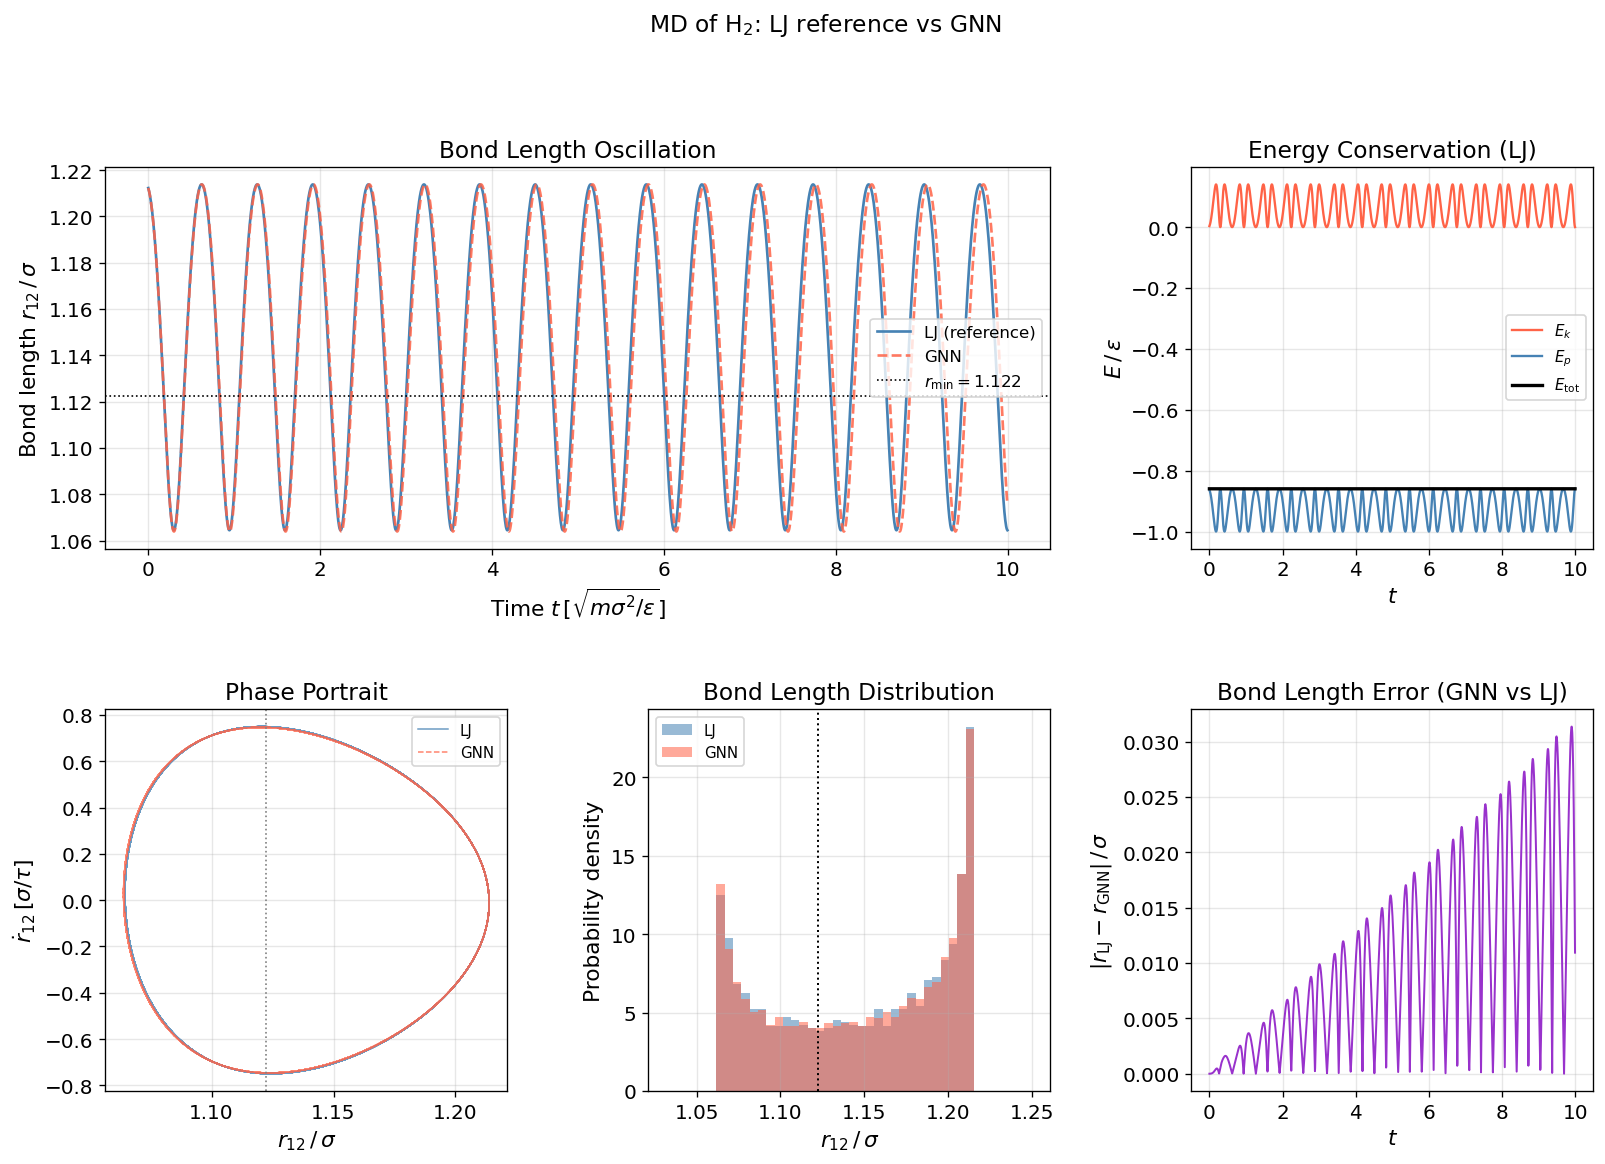

Mean |r_LJ - r_GNN| = 0.00992 sigma


In [11]:
t = traj_lj['t']
fig=plt.figure(figsize=(16,10))
gs =gridspec.GridSpec(2,3,hspace=0.42,wspace=0.35)

# bond length time series
ax=fig.add_subplot(gs[0,:2])
ax.plot(t,r_lj, color='steelblue',lw=1.6,label='LJ (reference)')
ax.plot(t,r_gnn,color='tomato',   lw=1.6,ls='--',label='GNN',alpha=0.85)
ax.axhline(R_MIN,color='k',ls=':',lw=1.0,label=rf'$r_{{\min}}={R_MIN:.3f}$')
ax.set(xlabel=r'Time $t\,[\sqrt{m\sigma^2/\varepsilon}]$',
       ylabel=r'Bond length $r_{{12}}\,/\,\sigma$',
       title='Bond Length Oscillation')
ax.legend(fontsize=10)

# energy conservation (LJ)
ax=fig.add_subplot(gs[0,2])
ax.plot(t,traj_lj['Ek'],  color='tomato',   lw=1.4,label=r'$E_k$')
ax.plot(t,traj_lj['Ep'],  color='steelblue',lw=1.4,label=r'$E_p$')
ax.plot(t,traj_lj['Etot'],color='k',        lw=2.0,label=r'$E_{\rm tot}$')
ax.set(xlabel=r'$t$',ylabel=r'$E\,/\,\varepsilon$',
       title='Energy Conservation (LJ)')
ax.legend(fontsize=9)

# phase portrait
ax=fig.add_subplot(gs[1,0])
ax.plot(r_lj[:-1], np.diff(r_lj)/DT, color='steelblue',lw=0.9,label='LJ', alpha=0.8)
ax.plot(r_gnn[:-1],np.diff(r_gnn)/DT,color='tomato',   lw=0.9,ls='--',label='GNN',alpha=0.8)
ax.axvline(R_MIN,color='grey',ls=':',lw=1.0)
ax.set(xlabel=r'$r_{{12}}\,/\,\sigma$',ylabel=r'$\dot r_{{12}}\,[\sigma/\tau]$',
       title='Phase Portrait')
ax.legend(fontsize=9)

# bond-length histogram
ax=fig.add_subplot(gs[1,1])
bins=np.linspace(0.97*min(r_lj.min(),r_gnn.min()),
                 1.03*max(r_lj.max(),r_gnn.max()),45)
ax.hist(r_lj, bins=bins,density=True,alpha=0.55,color='steelblue',label='LJ')
ax.hist(r_gnn,bins=bins,density=True,alpha=0.55,color='tomato',   label='GNN')
ax.axvline(R_MIN,color='k',ls=':',lw=1.2)
ax.set(xlabel=r'$r_{{12}}\,/\,\sigma$',ylabel='Probability density',
       title='Bond Length Distribution')
ax.legend(fontsize=9)

# trajectory error
ax=fig.add_subplot(gs[1,2])
ax.plot(t,np.abs(r_lj-r_gnn),color='darkorchid',lw=1.2)
ax.set(xlabel=r'$t$',ylabel=r'$|r_{\rm LJ}-r_{\rm GNN}|\,/\,\sigma$',
       title='Bond Length Error (GNN vs LJ)')

fig.suptitle(r'MD of H$_2$: LJ reference vs GNN',fontsize=14,y=1.01)
plt.tight_layout(); plt.show()
print(f'Mean |r_LJ - r_GNN| = {np.abs(r_lj-r_gnn).mean():.5f} sigma')


  SUMMARY -- GNN vs Lennard-Jones Reference
  Equilibrium bond length:
    LJ   r_min = 1.12365 sigma
    GNN  r_min = 1.12365 sigma   (err=0.00000)
  Well depth:
    LJ   E_min = -0.99996 eps
    GNN  E_min = -0.99482 eps   (err=0.00514)
  Energy RMSE: 0.08930 eps
  GNN params : 7,885


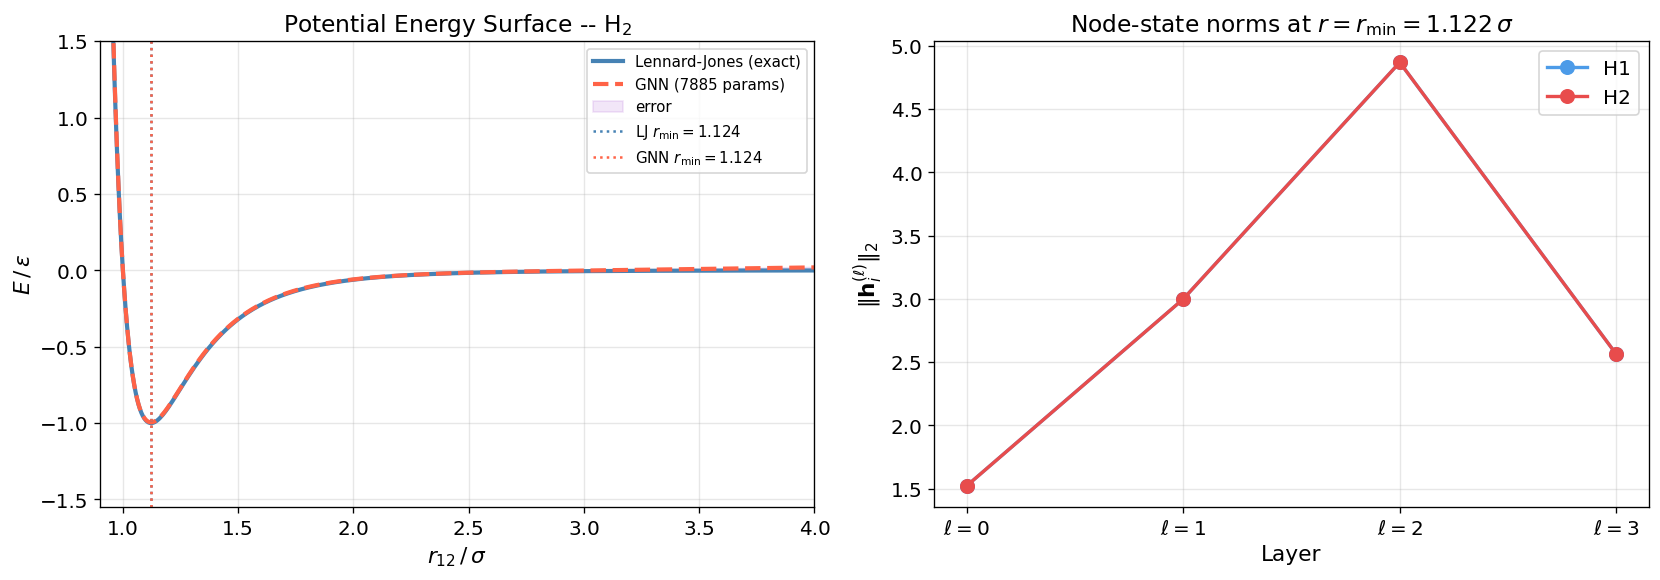

In [12]:
# full PES comparison
r_full =np.linspace(0.90,4.0,500)
E_lj_f =lj_potential(r_full)
E_gnn_f=np.array([gnn.forward(graph_from_r(r))*sig_E+mu_E for r in r_full])

r_eq_lj =r_full[E_lj_f.argmin()]; r_eq_gnn=r_full[E_gnn_f.argmin()]

print('='*55)
print('  SUMMARY -- GNN vs Lennard-Jones Reference')
print('='*55)
print(f'  Equilibrium bond length:')
print(f'    LJ   r_min = {r_eq_lj:.5f} sigma')
print(f'    GNN  r_min = {r_eq_gnn:.5f} sigma   (err={abs(r_eq_gnn-r_eq_lj):.5f})')
print(f'  Well depth:')
print(f'    LJ   E_min = {E_lj_f.min():.5f} eps')
print(f'    GNN  E_min = {E_gnn_f.min():.5f} eps   (err={abs(E_gnn_f.min()-E_lj_f.min()):.5f})')
print(f'  Energy RMSE: {np.sqrt(np.mean((E_gnn_f-E_lj_f)**2)):.5f} eps')
print(f'  GNN params : {gnn.n_params():,}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PES
ax=axes[0]
ax.plot(r_full,E_lj_f, color='steelblue',lw=2.5,label='Lennard-Jones (exact)')
ax.plot(r_full,E_gnn_f,color='tomato',   lw=2.5,ls='--',label=f'GNN ({gnn.n_params()} params)')
ax.fill_between(r_full,E_lj_f,E_gnn_f,alpha=0.12,color='darkorchid',label='error')
ax.axvline(r_eq_lj, color='steelblue',ls=':',lw=1.5,
           label=rf'LJ $r_{{\min}}={r_eq_lj:.3f}$')
ax.axvline(r_eq_gnn,color='tomato',   ls=':',lw=1.5,
           label=rf'GNN $r_{{\min}}={r_eq_gnn:.3f}$')
ax.set(xlim=(0.90,4.0),ylim=(-1.55,1.5),
       xlabel=r'$r_{{12}}\,/\,\sigma$',ylabel=r'$E\,/\,\varepsilon$',
       title=r'Potential Energy Surface -- H$_2$')
ax.legend(fontsize=9)

# node-state norms across layers
gnn.forward(graph_from_r(R_MIN))   # populate cache
ax=axes[1]
for atom,(color,label) in enumerate(zip(['#4C9BE8','#E84C4C'],['H1','H2'])):
    norms=[np.linalg.norm(gnn._H_layers[l][atom]) for l in range(gnn.L+1)]
    ax.plot(range(gnn.L+1),norms,'o-',color=color,label=label,lw=2,ms=8)
ax.set(xticks=range(gnn.L+1),
       xticklabels=[rf'$\ell={l}$' for l in range(gnn.L+1)],
       xlabel='Layer',
       ylabel=r'$\|\mathbf{h}_i^{(\ell)}\|_2$',
       title=rf'Node-state norms at $r=r_{{\min}}={R_MIN:.3f}\,\sigma$')
ax.legend()
plt.tight_layout(); plt.show()


---
## 8  Exercises

### Conceptual

1. **Symmetry.**  
   Prove that sum aggregation $\bar{\mathbf{m}}_i=\sum_{j\in\mathcal{N}(i)}\mathbf{m}_{ij}$
   is permutation-equivariant with respect to node labelling.
   Why does this matter for interatomic potentials?

2. **Graph Laplacian.**  
   Verify the eigenvalues $\lambda(L)=\{0,2\}$ for H$_2$ analytically.
   Compute the spectrum for a 3-atom equilateral triangle.

3. **Weisfeiler-Lehman expressivity.**  
   State when a GNN with sum aggregation is as powerful as the 1-WL isomorphism test.
   Give an example of two molecular graphs it cannot distinguish.

### Computational

4. **Newton's third law check.**  
   Verify numerically $\hat{\mathbf{F}}_{01}\approx-\hat{\mathbf{F}}_{10}$
   at $r=0.95,\,1.12,\,2.0\,\sigma$. Does the error correlate with the training error?

5. **Extend to 3D.**  
   Modify `MolecularGraph` to accept $d=3$ positions.
   Run an MD trajectory with a small off-axis perturbation and verify
   that the oscillation stays along the bond axis.

6. **Berendsen thermostat.**  
   Add velocity rescaling at each step:
   $$\mathbf{v}_i\leftarrow\mathbf{v}_i\sqrt{1+\frac{\Delta t}{\tau_T}\!\left(\frac{T_0}{T}-1\right)}$$
   Run at $k_BT=0.10\,\varepsilon$ and compare the bond-length histogram
   to the Boltzmann factor $p(r)\propto e^{-V_{\rm LJ}(r)/k_BT}$.

7. **Force-augmented loss.**  
   $$\mathcal{L}=\frac{1}{N}\sum_n\!\left[(E_n^{\rm pred}-E_n^{\rm LJ})^2+\lambda\sum_i\|\mathbf{F}_{i,n}^{\rm pred}-\mathbf{F}_{i,n}^{\rm LJ}\|^2\right]$$
   Choose $\lambda=0.05$; compare force errors before and after.

8. **Deeper / wider.**  
   Set $L=6$, $d_h=64$. Does the energy RMSE improve?
   What happens to MD trajectory stability?

### Research

9. **E(3)-equivariant GNN.**  
   Read Schütt et al. (SchNet, 2017) or Batzner et al. (NequIP, 2022).
   Describe the architectural change that makes **force prediction equivariant**
   (a vector output from the network, not finite differences).

10. **Transfer learning.**  
    Generate He-H training data (different $\varepsilon$, $\sigma$).
    Fine-tune the H$_2$ GNN on 30 He-H points; compare to training from scratch.

---
## References

| Reference | Relevance |
|-----------|----------|
| Gilmer et al., *Neural Message Passing for Quantum Chemistry*, ICML 2017 | MP-GNN framework |
| Battaglia et al., *Interaction Networks*, NeurIPS 2016 | InteractionNet |
| Schütt et al., *SchNet*, Nat. Commun. **8**, 13890 (2017) | Deep learning for mol. potentials |
| Batzner et al., *NequIP*, Nat. Commun. **13**, 2453 (2022) | E(3)-equivariant GNN for MD |
| Kingma & Ba, *Adam*, ICLR 2015 | Adam optimiser |
| Allen & Tildesley, *Computer Simulation of Liquids*, Oxford 1987 | MD algorithms |
| Lennard-Jones, Proc. R. Soc. A **106**, 441 (1924) | LJ potential |
| Behler & Parrinello, PRL **98**, 146401 (2007) | Neural-network potentials |

---
*All code runs with NumPy >= 1.21 and Matplotlib >= 3.4. No deep-learning framework required.*
